# Optimization

Nearly everything we do in this class is some form of an optimization problem.  These optimization problems primarily consist of a *loss function* or *objective function* $\mathcal{L}(\mathcal{D},w)$.  This loss function is a function on our *data* $\mathcal{D}$ and our *parameters* $w$, and which returns a scalar.  For a given application, we design a loss function which communicates how well our solution is doing.  For example, in K-Means clustering, our loss function was the total within-cluster variance, the data was the data points, and the parameters were our assignments of points to clusters.

In ML, we design these loss functions, and then count on mathematical and computational tools to find the parameters which result in the best possible version we can put together for our problem.  Again revisiting K-Means, the K-Means algorithm resulted in the better and better cluster assignments until the loss function couldn't seem to decrease any more; these assignments were our solution.

When we write optimization problems, we have to state a couple things aside from the loss function.  First, we state whether we want our loss function to be big or small, by stating whether the goal is to minimize or maximize it.  Second, we state the loss function.  Third, we explicitly state which variables in the loss function we can control to perform this optimization (our parameters).  Finally, there may be some additional constraints on the solution.

It can be useful to visualize a loss function as a surface in space.  For example, perhaps your loss function has two parameters.  As you change those parameters, the loss function increases, or decreases, meaning the surface rises or falls.  If minimizing the loss function, the goal is to find the spot on the surface with the smallest value.  The properties of the optimization problem determine if this minimum point is easy or hard to find.

<img src="lossSurface.png" width="500"/>

[*Which would you rather optimize?*](https://arxiv.org/pdf/1712.09913.pdf)

Fully understanding how we can solve these optimization problems is deeper than we can reasonably go in an undergraduate ML class.  But, some context is important in understanding what your solutions might look like, and how long we can expect solutions to take.

From easiest to hardest, we can break these down into:

- Problems we can solve in *closed form*.
- Problems which are *convex*.
- Problems which are *nonconvex*.
- Problems which are *discrete*.

## Closed Form

You have actually seen this before, repeatedly, in Calculus class, where you were asked to minimize or maximize a function.  What did you do?  You symbolically calculated the gradient of the function, set it equal to zero, then algebraically solved for your variables (parameters).  This gave you a *closed-form solution* of the form $w=something$, where you could calculate the minimum exactly, without having to do any iterative algorithm.  This is generally very fast!  We like it!  It doesn't happen very often, either because the gradient is not possible to write symbolically, or you cannot algebraically isolate the parameters.  In all the rest of the problems, we have to do some kind of iterative guess-check-improve algorithm instead.

An example of a closed form problem you have encountered before is Linear Regression.  In (unregularized) linear regression, with a $n\times k$ data matrix $X$ with rows $x_i$ and a $n\times 1$ target vector $y$, we are trying to solve the following optimization problem:

$$
\begin{aligned}
& \min_w \sum_{i}(x_iw-y_i)^2\\
=& \min_w \|Xw-y\|^2\\
=& \min_w (w^TX^TXw-2w^TX^Ty+y^Ty)
\end{aligned}
$$

To solve this, we need to set the gradient with respect to w equal to zero.  For this, we'll use some identities you may not remember:

$$
\nabla_w(w^TAw)=(A+A^T)w \\
$$
$$
\nabla_w(w^Tb)=b \\
$$
$$
(A^T B)^T = B^T A \\
$$

When we apply those, set it equal to zero, then solve for $w$...

$$
\begin{aligned}
\nabla_w(w^TX^TXw-2w^TX^Ty+y^Ty)=&2(X^TXw-X^Ty)\\
0=&2(X^TXw-X^Ty)\\
X^TXw=&X^Ty\\
w=&(X^TX)^{-1}X^Ty
\end{aligned}
$$

So, to perform linear regression, we need only calculate $(X^TX)^{-1}X^Ty$, and that's our desired $w$.  The slowest part of this is calculating that inverse of a $k\times k$ matrix, which is about $O(k^3)$.  For small $k$, that's very, very fast! This is one reason why linear regression is always a good thing to try.

Note that this doesn't change if we do ridge regression, it's just that after going through a similar derivation, we calculate $(X^TX-\lambda I)^{-1}X^Ty$ instead.

## Convex Optimization Problems

If you cannot solve directly for your solution, you hope your problem is *convex*. First, a definition of the word [*convex*](https://en.wikipedia.org/wiki/Convex_function): a surface is convex if for every pair of points on the surface, you can draw a straight line between them without crossing the surface.  An optimization problem is convex if: (1) The loss function is convex, and (2) the constraints (if there are any) define a convex surface.  Convexity implies a very large number of other properties that we can count on when doing our optimization.  For example, it is impossible for a convex problem to have more than one minimum; if you find a local minimum, you've found the global minimum. (However, if a problem has only one minimum, that does not necessarily mean it is convex.)

As another example, imagine a one-dimensional convex optimization problem, like finding the bottom of a parabola.  If you were to choose two random points on the parabola, and discover the derivative is negative for one, and positive for the other, the minimum must lie between them (immediately, perhaps you could imagine some fast binary-search-type algorithm to find the minimum).

These nice properties allow us to write optimization algorithms which are not as fast as closed-form, but are still very fast.  Most run in polynomial time, and the rest are technically NP-hard, but run very quickly in practice.  We like them! They generally look like a "guess-and-check," where you propose a random solution, then see in what way it's wrong, and iteratively improve it.  That iterative improvement is much faster in convex problems than in the nonconvex problems discussed next.

Examples of these convex problems include Logistic Regression and Linear Regression with the LASSO.

The below code creates a visualization of a convex loss surface. Suppose we have an algorithm with two parameters which we would like to minimize. We can create a 3D plot where the X dimension is the value of the first parameter, the Y dimension is the value of the second parameter, and the Z dimension is the Loss of that algorithm on our data for each pairing of X and Y.  The below is convex.

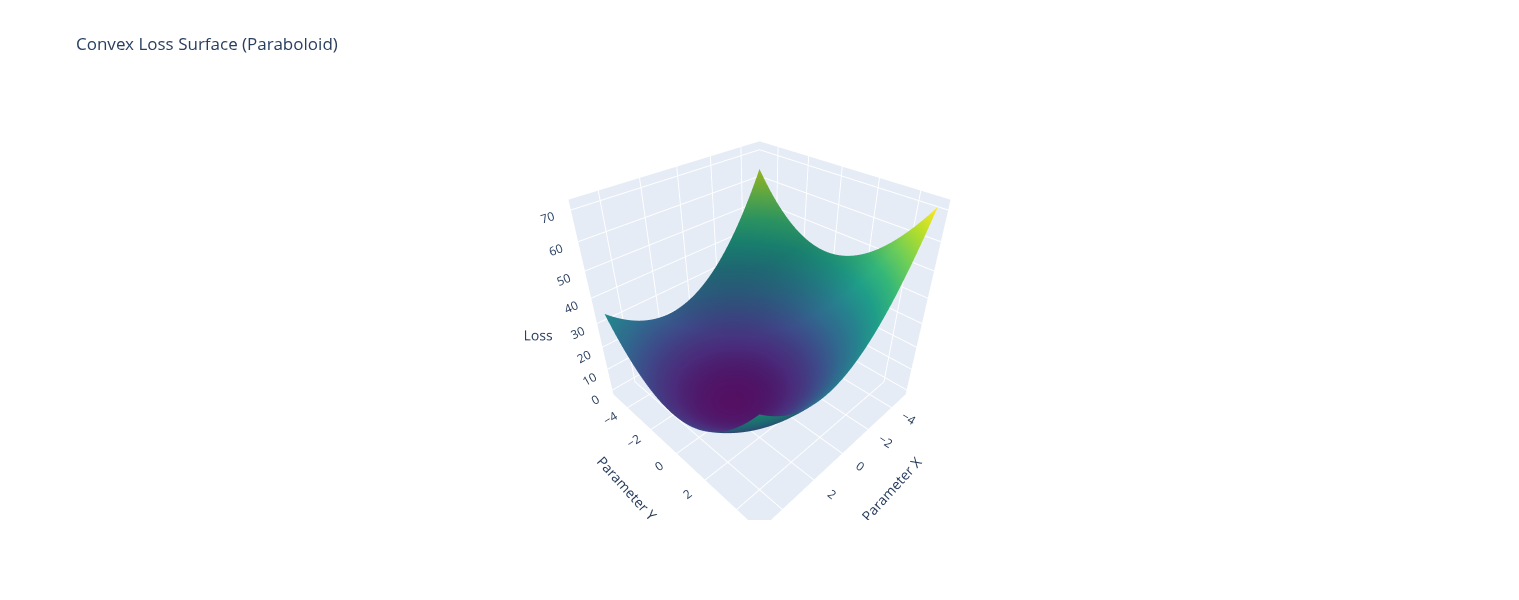

In [1]:
import numpy as np
import plotly.graph_objects as go

# Define grid
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# Convex Function: Simple Paraboloid
# f(x, y) = x^2 + y^2
Z = (X-1.5)**2 + (Y+.35)**2

# Create Plot
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Viridis', showscale=False)])

fig.update_layout(
    title='Convex Loss Surface (Paraboloid)',
    scene=dict(
        xaxis_title='Parameter X',
        yaxis_title='Parameter Y',
        zaxis_title='Loss',
        aspectmode='cube'
    ),
    width=800,
    height=600
)

fig.show()

## Nonconvex Optimization Problems

These are hairier.  If your problem is not convex, then you do not have any of those nice properties to use as a toehold in building a fast algorithm, and your problem is NP-Hard.  Generally, we have few ideas aside from some variation of stochastic gradient descent, which is our workhorse that will always find you some minimum, eventually.  When we find a minimum, we don't even know for sure that it's a global minimum, rather than some worse local minimum.

The time this iteration takes depends heavily on how well behaved the optimization problem is.  For example, in the pictured example at the top of this page, both surfaces are nonconvex.  However, optimization will run much quicker on the one on the right.

Our neural nets will lie in this space.

Below are two nonconvex surfaces. The first is nonconvex but nonetheless has one local minimum. The second is nonconvex and has many local minima. These both take more time to optimize than the convex example above, but of course the first one is better behaved than the second.

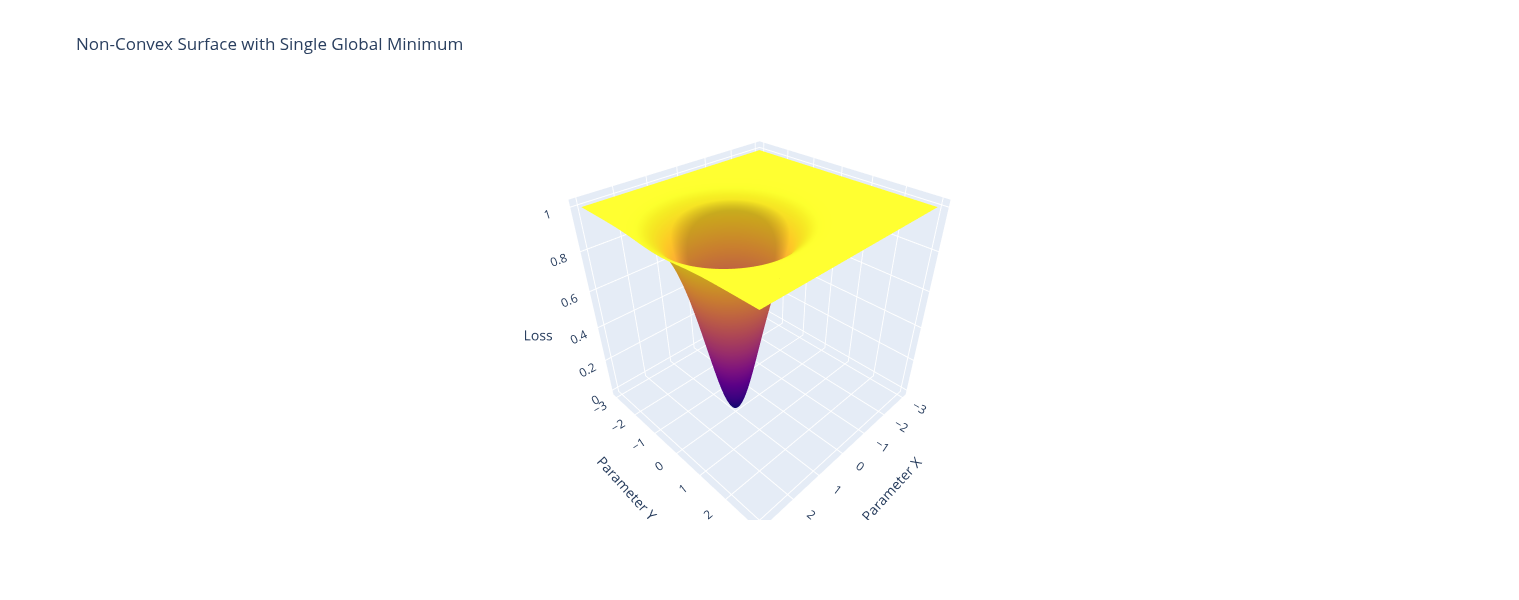

In [2]:
# Define grid
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)

# Non-convex Function with Single Minimum: Gaussian Well
# f(x, y) = 1 - exp(-(x^2 + y^2))
Z = 1 - np.exp(-((X-1)**2 + Y**2))

# Create Plot
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Plasma', showscale=False)])

fig.update_layout(
    title='Non-Convex Surface with Single Global Minimum',
    scene=dict(
        xaxis_title='Parameter X',
        yaxis_title='Parameter Y',
        zaxis_title='Loss',
        aspectmode='cube'
    ),
    width=800,
    height=600
)

fig.show()

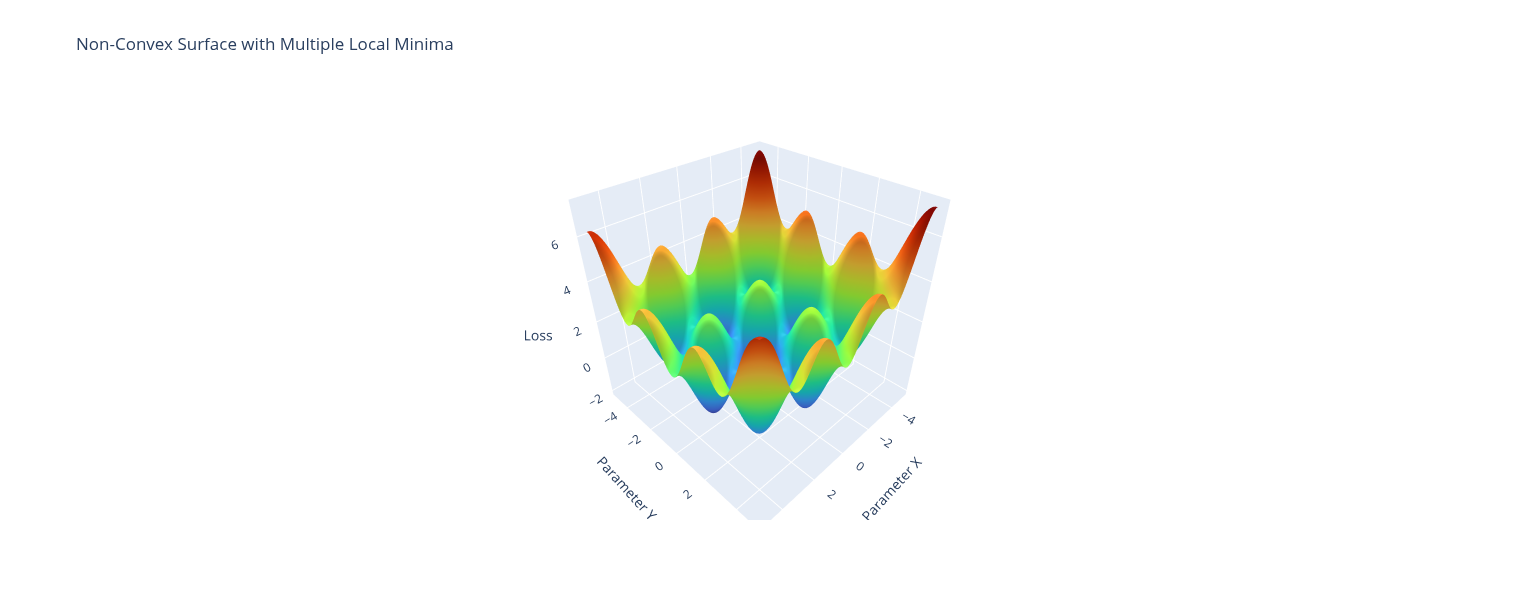

In [3]:
# Define grid
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# Non-convex Function with Local Minima
# Combination of quadratic bowl and trigonometric waves
Z = 0.1 * ((X-.5)**2 + Y**2) - np.cos(2*X) - np.cos(2*Y)

# Create Plot
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Turbo', showscale=False)])

fig.update_layout(
    title='Non-Convex Surface with Multiple Local Minima',
    scene=dict(
        xaxis_title='Parameter X',
        yaxis_title='Parameter Y',
        zaxis_title='Loss',
        aspectmode='cube'
    ),
    width=800,
    height=600
)

fig.show()

## Discrete Optimization Problems

If your parameters are discrete, we can't even calculate a gradient, because the problem is *nondifferentiable*.  Here, we're really up a creek, and have to do some approximate algorithm like our KMeans algorithm to find some local minimum.  Discrete optimization is generally NP-Hard, and we have to sacrifice optimality for speed (ie, we accept a pretty good, though maybe not the best, solution, in exchange for finishing our optimization before the sun goes out).

# Stochastic Gradient Descent

Most of the algorithms used to perform optimization are not necessary to understand to begin studying ML.  But, you can't get far without understanding one of the most useful algorithms in all of Computer Science: **Stochastic
Gradient Descent (SGD)**.

Suppose we have a function we'd like to minimize, $\mathcal{L}(\mathcal{D},w)$, where $\mathcal{D}$ is your
data, and $w$ is some multi-dimensional vector.  You can't change $\mathcal{D}$, because
your data's your data, but you can change your parameters $w$.  We'd like to do the closed form
thing above, and it would be great to take the gradient of $\mathcal{L}$ with respect to
$w$ ($\nabla_w \mathcal{L}$), set it equal to 0, and solve for $w$, to find all minima,
maxima, and saddle points.  This can be difficult or impossible, either because there's a
whole lot of such flat points, or because solving for $w$ is not possible.

In that very common case, what we *can* do is find some optimum iteratively.  The idea here is to start
with a random $w$.  Now, changing the values of $w$ would result in $\mathcal{L}$ either
increasing or decreasing.  If you want to know the direction in which $\mathcal{L}$
increases the quickest, well, that's the gradient.  So, since we're
minimizing, we take the gradient of $\mathcal{L}$, and change $w$ just a little bit in
the opposite direction, so that we're taking a step downhill.  In notation,
that looks like this:

$$
w\leftarrow w-\alpha (\nabla_w \mathcal{L}(\mathcal{D},w))^T
$$

That algorithm is gradient descent.  $\alpha$ here is called the *learning
rate*, and is just a scalar that says how big of a step are we taking in the
downhill direction.  We do this, over and over again, until convergence or
we've had enough.

Now, how big should our learning rate be?  Too big, and we'll step right over
our minimum, or start oscillating.  Too small, and it'll take a really long
time.  /shrugemoji.  Try some different values for your problem, and see how
they do.

Wonderful. However, there are two problems:
- calculating the gradient at each iteration may be very slow because it involves accessing every data point. If we have lots and lots of data, this is a slow thing to do.
- by strictly walking downhill, we might end up in some local minimum. What we'd like is to avoid the presumably-smaller wells of the local minima, and end up in the presumably-bigger well of the global minimum.

Our solution to both of these problems are the same. We assume that the gradient calculated on a small random subset of our data is a little, but not a lot, different from what it would be if we calculated it on the whole dataset. Calculating on a small subset of the data is much faster, solving our first problem. By having our gradient be a little bit wrong, we introduce some random jitter into our iterative path - random jitter gives us a chance to bounce out of small minimal wells and into the bigger minimal wells of global minima. Because this subset of data is random, we call this modification "stochastic gradient descent" (SGD).

```{admonition} Definition: Stochastic
Randomly determined; having a random probability distribution or pattern that may be analyzed statistically but may not be predicted precisely.
```

With SGD, we have very few guarantees about the result.  If $\alpha$ is too
large, you could oscillate, and not converge at all.  You could converge, but
to a local minimum.  It might take a lot of iterations.  It might take just a
few.  But, when you have a difficult-to-optimize function, sometimes it's all
you have, and it tends to work pretty well.

## Gradient Descent Demo

To demonstrate Gradient Descent, we will minimize the function $f(x,y)=0.25x^4-x^2+.2x+.5y^2$. In this case, we have two parameters, $x$ and $y$.

Now, this has no inherent ML meaning, but the key thing is, if we change $x$ or $y$, the value of the output will change - and we're trying to find the values of $x$ and $y$ that minimize it.  First, here's what the loss function looks like:

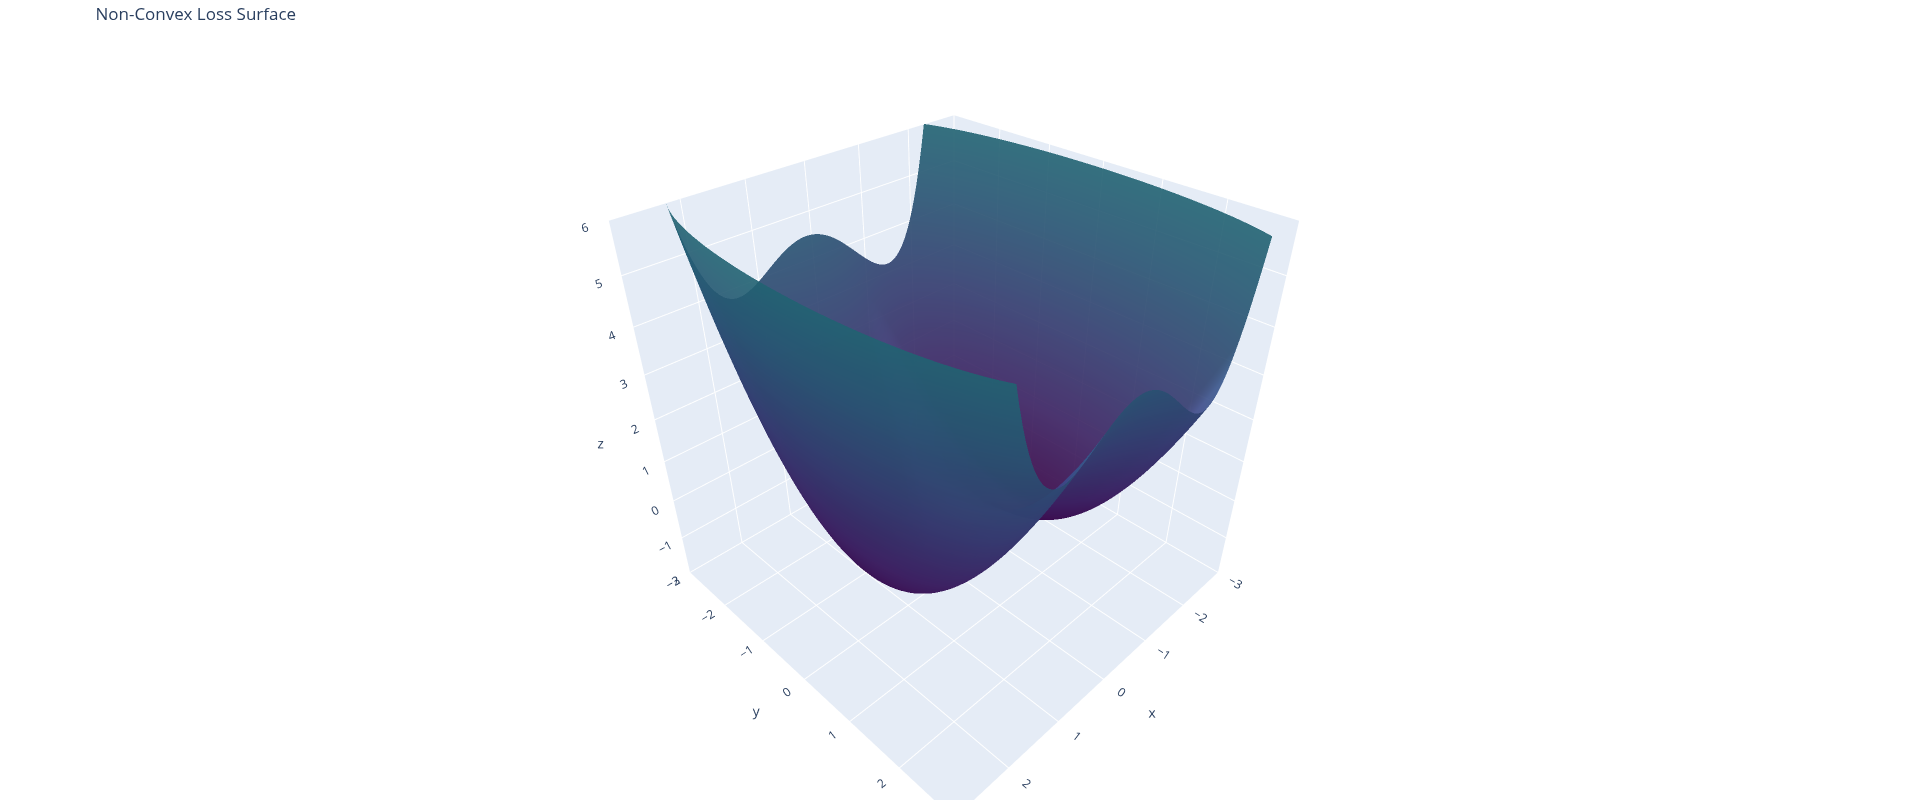

In [4]:
import numpy as np
import plotly.graph_objects as go

np.random.seed(2) # For reproducibility


def loss_function(x, y):
    """
    Calculates the loss for a given x and y.
    """
    return 0.25 * x**4 - x**2 + 0.20 * x + 0.50 * y**2

# 1. Setup the Grid
x_range = np.linspace(-3, 3, 100)
y_range = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_range, y_range)

# 2. Calculate Loss (Z)
Z = loss_function(X, Y)

# 3. Plotting with Plotly
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='Viridis', opacity=0.9, showscale=False)])

fig.update_layout(
    title='Non-Convex Loss Surface',
    autosize=True,
    width=None,
    height=800,
    margin=dict(l=0, r=0, b=0, t=40), # remove whitespace margins
    scene=dict(
        aspectmode='cube', # Forces X, Y, and Z to have equal lengths
        xaxis=dict(nticks=10, range=[-3, 3]),
        yaxis=dict(nticks=10, range=[-3, 3]),
        zaxis=dict(nticks=10, range=[-2, 6]), # Adjust Z range if needed
    )
)

fig.show()

You'll notice it has local minima, global minima, and is nonconvex. So, we have no choice but to do gradient descent. To start, we create a random guess for $x$ and $y$.  That random guess is visible in the below plot as a red diamond.

Initial Guess: x=-0.3200, y=-2.3704, Loss=2.6455


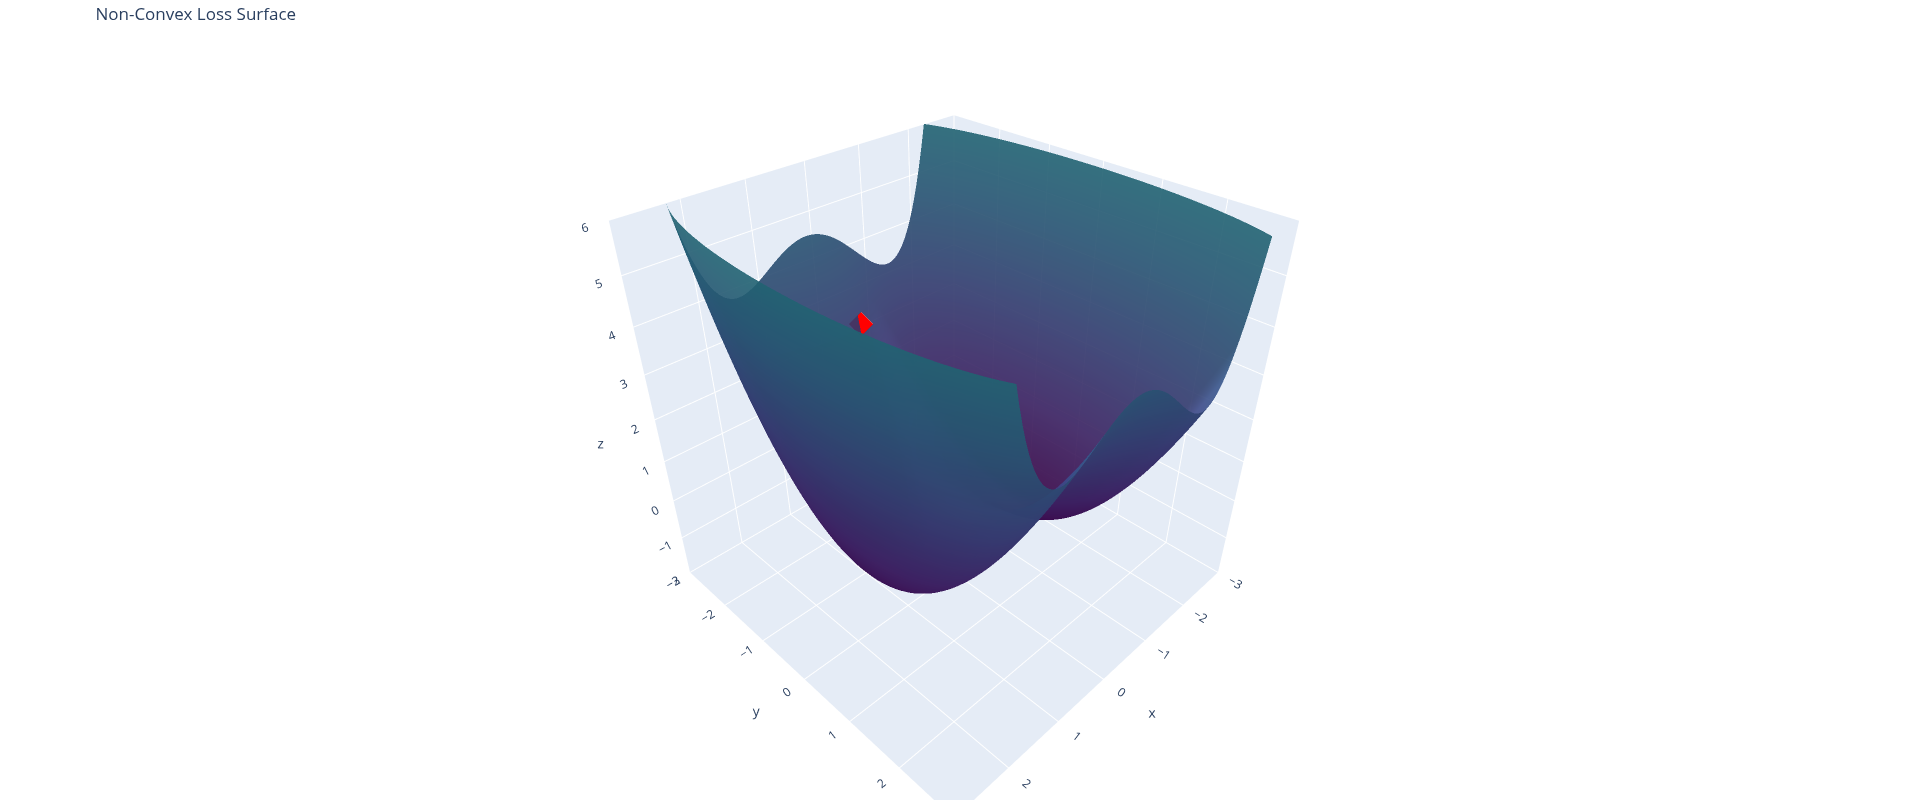

In [5]:
# 1. Generate a random initial guess
# We restrict the range slightly to ensuring the point is clearly visible
start_x = np.random.uniform(-2.5, 2.5)
start_y = np.random.uniform(-2.5, 2.5)
start_z = loss_function(start_x, start_y)

print(f"Initial Guess: x={start_x:.4f}, y={start_y:.4f}, Loss={start_z:.4f}")

# 2. Add the point to the existing plot
# This uses the 'fig' object created in the previous cell
fig.add_trace(
    go.Scatter3d(
        x=[start_x],
        y=[start_y],
        z=[start_z],
        mode='markers',
        marker=dict(
            size=8,
            color='red',
            symbol='diamond',
            opacity=1.0
        ),
        name='Initial Guess'
    )
)

# 3. Render the updated figure
fig.show()

We now calculate the gradient $\nabla_{x,y} f(x,y)$, which is to say, $\frac{\partial f(x,y)}{\partial x}$ and $\frac{\partial f(x,y)}{\partial y}$. They're not hard!

$$\frac{\partial f(x,y)}{\partial x} = x^3-2x+.2$$

$$\frac{\partial f(x,y)}{\partial y}=y$$

That makes a vector pointing in the direction that most steeply uphill from the estimate. We want to move in the opposite direction. The red "cone" points in the direction we should step.

Gradient at (-0.320, -2.370): <0.807, -2.370>


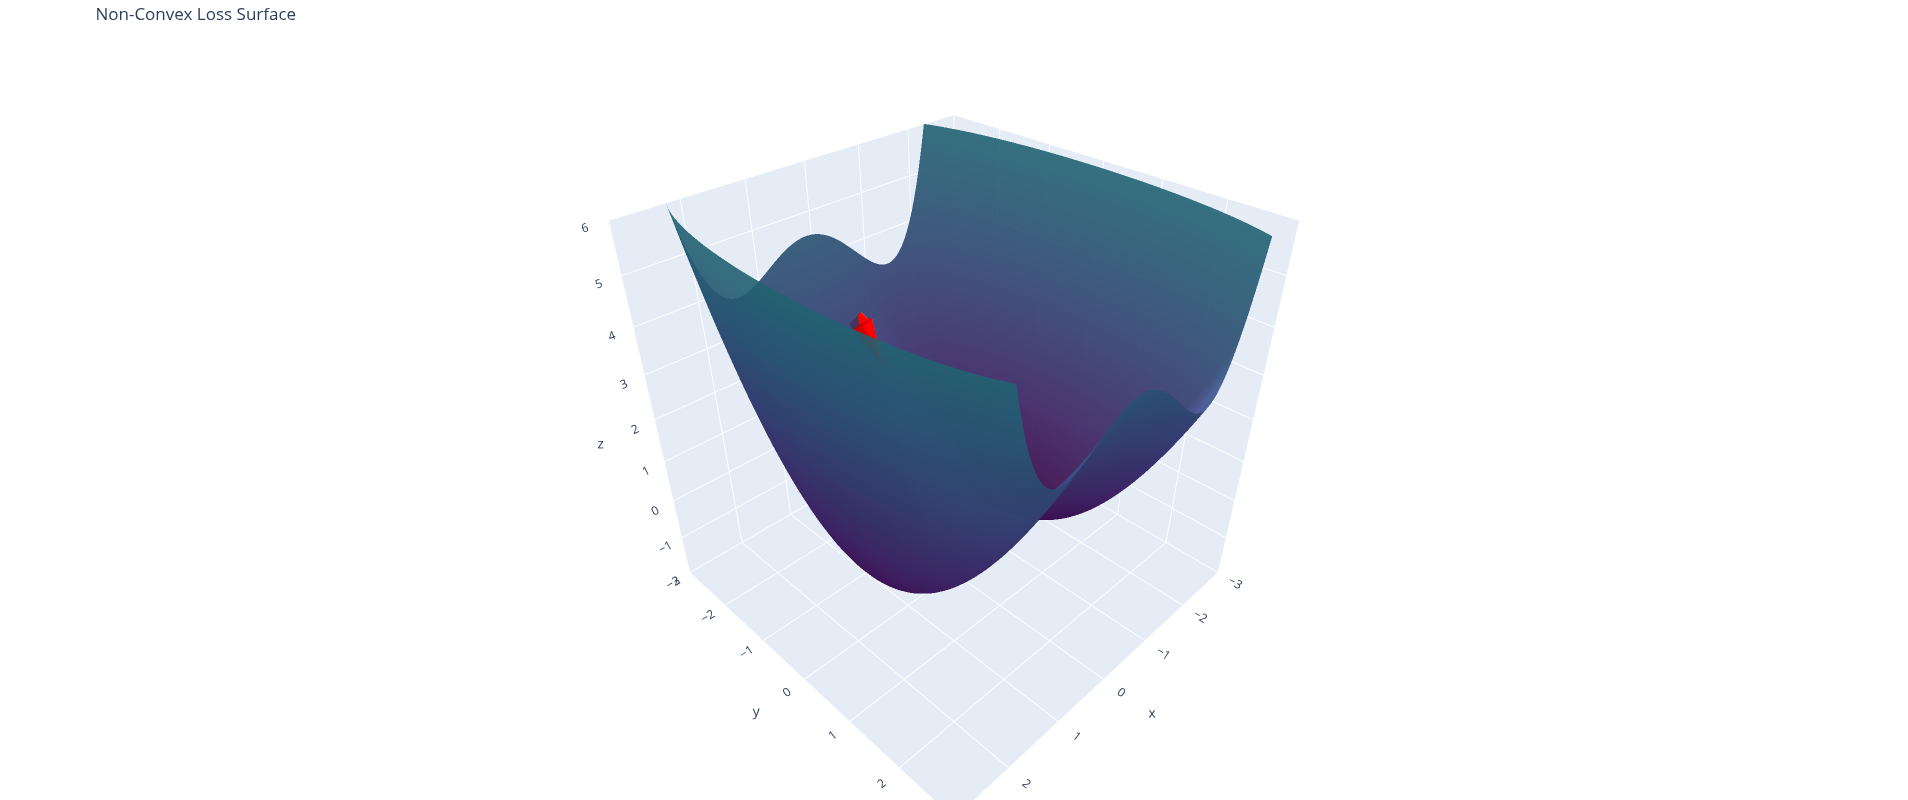

In [6]:
def calculate_gradient(x, y):
    """
    Calculates the gradient of the tilted double-well potential.
    f(x, y) = 0.25*x^4 - x^2 + 0.20*x + 0.50*y^2
    """
    # Partial derivative with respect to x
    dx = x**3 - 2*x + 0.20
    
    # Partial derivative with respect to y
    dy = y
    
    return dx, dy

def overlay_gradient_arrow(fig, x, y, visual_length=0.75):
    """
    Adds a normalized 3D cone representing the negative gradient 
    to the existing Plotly figure.
    
    visual_length: The approximate length of the arrow in axis units. 
                   Since axes are -3 to 3, 0.75 is a reasonable default.
    """
    # 1. Calculate raw gradient vectors
    grad_x, grad_y = calculate_gradient(x, y)
    z_val = loss_function(x, y)

    # Descent direction in XY plane
    u_raw = -grad_x 
    v_raw = -grad_y 
    # Change in Z along that direction
    w_raw = -(grad_x**2 + grad_y**2)

    # 2. Normalize vector to fix visual size
    # Calculate magnitude of the 3D vector
    magnitude = np.sqrt(u_raw**2 + v_raw**2 + w_raw**2)
    
    # Avoid division by zero at local extrema
    if magnitude < 1e-9:
        print(f"Gradient is near zero at ({x:.3f}, {y:.3f}). Skipping arrow.")
        return

    # Scale components to the desired visual length
    u = (u_raw / magnitude) * visual_length
    v = (v_raw / magnitude) * visual_length
    w = (w_raw / magnitude) * visual_length

    # 3. Add the Cone trace with absolute sizing
    fig.add_trace(
        go.Cone(
            x=[x], y=[y], z=[z_val],    # Anchor point
            u=[u], v=[v], w=[w],        # Normalized vector components
            sizemode="absolute",        # Use the absolute values of u,v,w for size
            sizeref=1,                  # Reference factor of 1
            anchor="tail",              # Anchor the cone at the tail
            showscale=False,
            colorscale=[[0, 'rgb(255,0,0)'], [1, 'rgb(255,0,0)']], # Solid red
            name='Gradient Vector'
        )
    )
    
    print(f"Gradient at ({x:.3f}, {y:.3f}): <{grad_x:.3f}, {grad_y:.3f}>")

# Clear previous gradient traces if re-running this cell repeatedly
# to avoid cluttered plot.
fig.data = [trace for trace in fig.data if trace.name not in ['Gradient Vector']]

# Add the new, normalized arrow
overlay_gradient_arrow(fig, start_x, start_y)
fig.show()

We can then subtract (adding it would move us uphill, and we're going downhill) this gradient, giving us a new estimate. We repeat over and over again until we find a minimum.

Start: (-0.320, -2.370) -> Loss: 2.646
End:   (-1.462, -0.182) -> Loss: -1.271


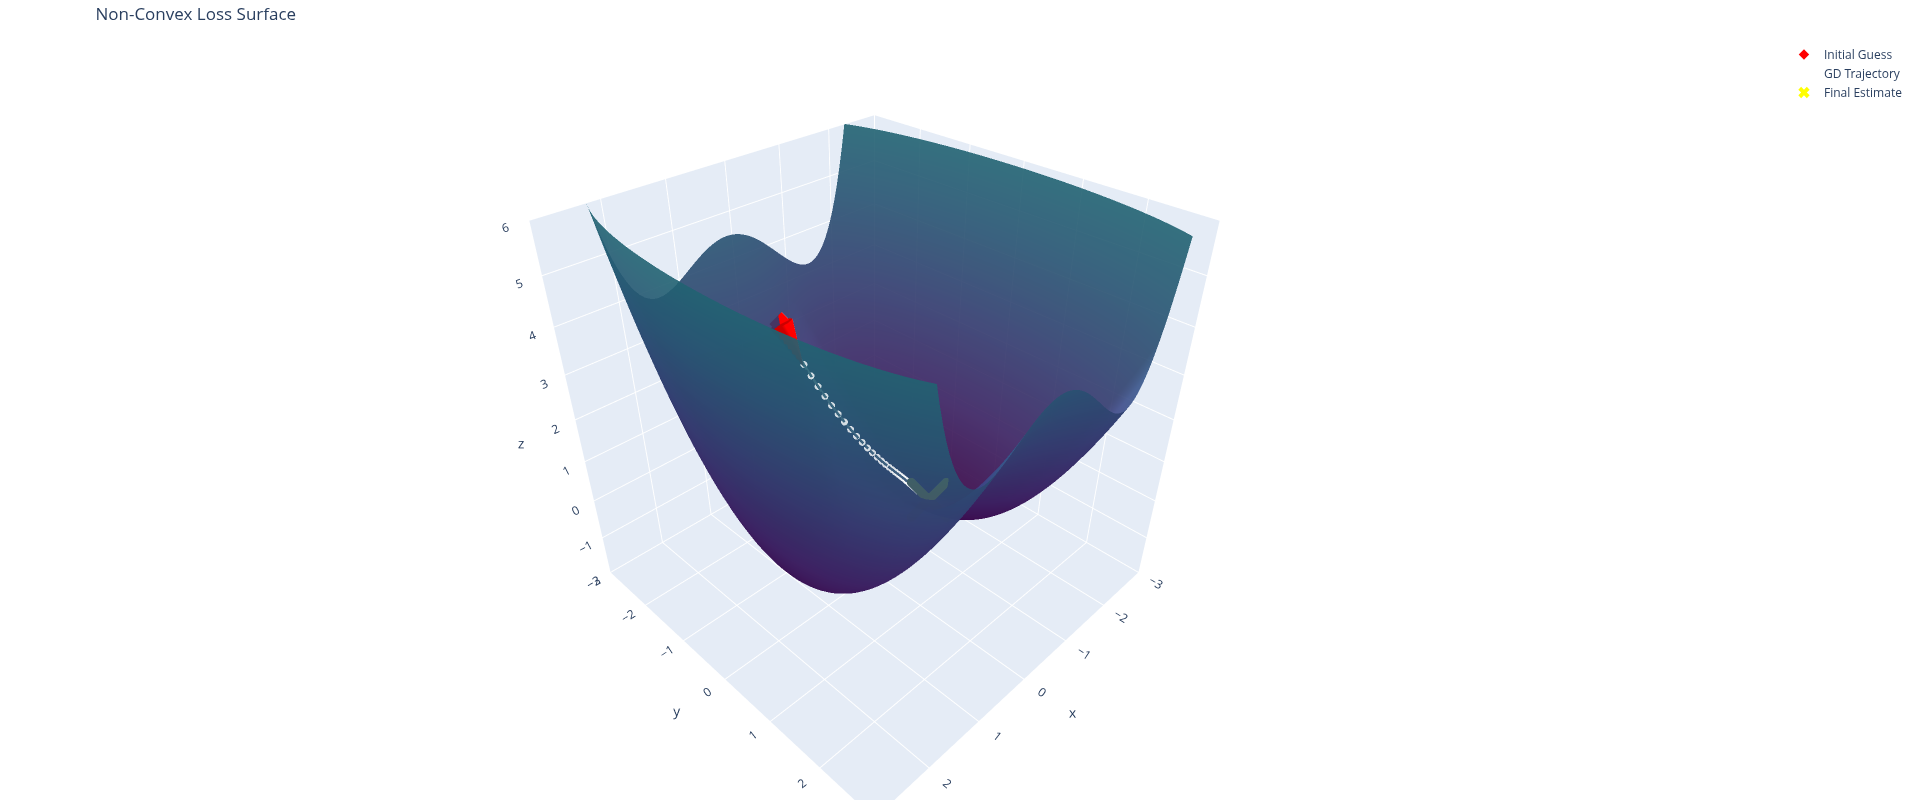

In [7]:
def run_gradient_descent(start_x, start_y, learning_rate=0.05, n_iterations=50):
    """
    Performs standard Gradient Descent.
    Returns lists of x, y, and z coordinates for the path.
    """
    # Initialize history with starting point
    path_x = [start_x]
    path_y = [start_y]
    path_z = [loss_function(start_x, start_y)]

    curr_x, curr_y = start_x, start_y

    for i in range(n_iterations):
        # 1. Calculate Gradient
        grad_x, grad_y = calculate_gradient(curr_x, curr_y)

        # 2. Update Parameters (Descent step)
        curr_x = curr_x - learning_rate * grad_x
        curr_y = curr_y - learning_rate * grad_y

        # 3. Store new position
        path_x.append(curr_x)
        path_y.append(curr_y)
        path_z.append(loss_function(curr_x, curr_y))

    return path_x, path_y, path_z

# --- Execution ---

# Parameters
lr = .05
steps = 50

# Run the optimization
px, py, pz = run_gradient_descent(start_x, start_y, learning_rate=lr, n_iterations=steps)

# --- Visualization ---

# 1. Add the Path Trajectory
fig.add_trace(
    go.Scatter3d(
        x=px,
        y=py,
        z=pz,
        mode='lines+markers',
        marker=dict(
            size=4,
            color='white',
            symbol='circle',
            opacity=0.8
        ),
        line=dict(
            color='white',
            width=5
        ),
        name='GD Trajectory'
    )
)

# 2. Highlight the Final Position
fig.add_trace(
    go.Scatter3d(
        x=[px[-1]],
        y=[py[-1]],
        z=[pz[-1]],
        mode='markers',
        marker=dict(
            size=10,
            color='yellow',
            symbol='x'
        ),
        name='Final Estimate'
    )
)

print(f"Start: ({px[0]:.3f}, {py[0]:.3f}) -> Loss: {pz[0]:.3f}")
print(f"End:   ({px[-1]:.3f}, {py[-1]:.3f}) -> Loss: {pz[-1]:.3f}")

fig.show()